# EDA + ETL

This notebook is the shared workspace for Stage 4 sample EDA, the Stage 4a and Stage 5a transforms, and the downstream SteamRec ETL outputs built from those staged artifacts.


In [1]:
%reset -f
# Resolve the project root no matter whether Jupyter starts in the repo root or the notebook directory.
from pathlib import Path
import datetime as dt
import sys

ETL_START_TIME = dt.datetime.now().astimezone()
print(f"ETL start: {ETL_START_TIME.isoformat(timespec='seconds')}")

candidates = [
    Path.cwd().resolve(),
    Path.cwd().resolve().parent,
    Path.cwd().resolve() / "steam-crawler",
    Path.cwd().resolve().parent / "steam-crawler",
]
ROOT_DIR = next(path for path in candidates if (path / "requirements.txt").exists())
REQUIREMENTS_FILE = ROOT_DIR / "requirements.txt"
ROOT_DIR


ETL start: 2026-04-23T20:54:11+08:00


PosixPath('/Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler')

In [2]:
# Install every runtime dependency declared in requirements.txt into the current notebook kernel environment.
print(f"Installing notebook dependencies from {REQUIREMENTS_FILE}")
!{sys.executable} -m pip install -r "{REQUIREMENTS_FILE}"

SRC_DIR = ROOT_DIR / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

SRC_DIR


Installing notebook dependencies from /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/requirements.txt


PosixPath('/Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/src')

In [3]:
# Load the crawler env with overrides enabled, resolve the configured data directory, and validate the Kaggle credentials.
import importlib
import os
import shutil
from pathlib import Path
from tempfile import TemporaryDirectory

import kagglehub
import steam_crawler.config as steam_config

steam_config = importlib.reload(steam_config)

ENV_PATH = steam_config.load_project_env(ROOT_DIR, override=True)
DATA_DIR = steam_config.resolve_data_dir(ROOT_DIR)
STAGE_04_PATH = DATA_DIR / "stage_04_selected_games.csv"
STAGE_04A_CSV_PATH = DATA_DIR / "stage_04a_selected_games.csv"
STAGE_04A_PARQUET_PATH = DATA_DIR / "raw_selected_games.parquet"
STAGE_05A_PARQUET_PATH = DATA_DIR / "raw_reviews_dataset.parquet"
KAGGLE_SHARED_DATASET_HANDLE = f"{os.getenv('KAGGLE_USERNAME', '')}/steam-cs5242-dataset" if os.getenv('KAGGLE_USERNAME') else None

required_env = {
    "KAGGLE_USERNAME": os.getenv("KAGGLE_USERNAME"),
    "KAGGLE_API_TOKEN": os.getenv("KAGGLE_API_TOKEN"),
}
missing_env = [name for name, value in required_env.items() if not value]
if missing_env:
    raise RuntimeError(
        "Missing required Kaggle credentials: "
        + ", ".join(missing_env)
        + ". Add them to the environment or to steam-crawler/.env before running this notebook."
    )

KAGGLE_USERNAME = required_env["KAGGLE_USERNAME"]
KAGGLE_SHARED_DATASET_HANDLE = f"{KAGGLE_USERNAME}/steam-cs5242-dataset"
os.environ.setdefault("KAGGLE_KEY", required_env["KAGGLE_API_TOKEN"])

def upload_kaggle_dataset_snapshot(
    dataset_handle: str,
    dataset_files: dict[str, Path],
    *,
    version_notes: str = "",
) -> dict[str, object]:
    if dataset_handle.count("/") != 1:
        raise ValueError(
            "Kaggle dataset handle must look like '<KAGGLE_USERNAME>/<DATASET_SLUG>'."
        )

    staged_files: dict[str, str] = {}
    with TemporaryDirectory(prefix="kagglehub_dataset_") as tmp_dir_name:
        tmp_dir = Path(tmp_dir_name)
        for target_name, source_path in dataset_files.items():
            source_path = Path(source_path)
            if not source_path.exists():
                continue
            staged_path = tmp_dir / target_name
            staged_path.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(source_path, staged_path)
            staged_files[target_name] = str(source_path)

        if not staged_files:
            raise FileNotFoundError(
                "No source parquet files were found for the Kaggle dataset snapshot."
            )

        kagglehub.dataset_upload(
            dataset_handle,
            str(tmp_dir),
            version_notes=version_notes,
        )

    dataset_url = f"https://www.kaggle.com/datasets/{dataset_handle}"
    print(f"Uploaded {len(staged_files)} parquet file(s) to {dataset_url}")
    for target_name, source_path in staged_files.items():
        print(f"- {target_name}: {source_path}")
    return {
        "handle": dataset_handle,
        "url": dataset_url,
        "files": staged_files,
        "version_notes": version_notes,
    }

if not STAGE_04_PATH.exists():
    raise FileNotFoundError(f"Stage 4 output not found: {STAGE_04_PATH}")

print(f"ROOT_DIR: {ROOT_DIR}")
print(f"ENV_PATH: {ENV_PATH}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"STAGE_04_PATH: {STAGE_04_PATH}")
print(f"STAGE_04A_CSV_PATH: {STAGE_04A_CSV_PATH}")
print(f"STAGE_04A_PARQUET_PATH: {STAGE_04A_PARQUET_PATH}")
print(f"STAGE_05A_PARQUET_PATH: {STAGE_05A_PARQUET_PATH}")
print(f"Kaggle credentials: ready for kagglehub as {KAGGLE_USERNAME}")
print(f"Shared Kaggle dataset handle: {KAGGLE_SHARED_DATASET_HANDLE}")


ROOT_DIR: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler
ENV_PATH: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/.env
DATA_DIR: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data
STAGE_04_PATH: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/stage_04_selected_games.csv
STAGE_04A_CSV_PATH: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/stage_04a_selected_games.csv
STAGE_04A_PARQUET_PATH: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/raw_selected_games.parquet
STAGE_05A_PARQUET_PATH: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/raw_reviews_dataset.parquet
Kaggle credentials: ready for kagglehub as gitaalekhyapaul
Shared Kaggle dataset handle: gitaalekhyapaul/steam-cs5242-dataset


In [4]:
import pandas as pd
from IPython.display import display

stage_04_df = pd.read_csv(STAGE_04_PATH)
print(f"Loaded Stage 4 dataframe: {stage_04_df.shape[0]:,} rows x {stage_04_df.shape[1]} columns")
display(stage_04_df.head())


Loaded Stage 4 dataframe: 9,598 rows x 15 columns


,appid,name,last_modified,price_change_number,raw_app_json,details_success,type,category_ids,category_descriptions,recommendations_total,raw_details_json,eligible_for_sampling,sample_rank,random_seed,sampled_at
0,10,Counter-Strike,1745368572,34672985,"{""appid"":10,""name"":""Counter-Strike"",""last_modi...",True,game,1|49|36|37|66|68|75|69|8|62,Multi-player|PvP|Online PvP|Shared/Split Scree...,167351,"{""10"":{""success"":true,""data"":{""type"":""game"",""n...",True,1,5242,2026-04-15T15:59:56.102758+00:00
1,20,Team Fortress Classic,1745368565,34672985,"{""appid"":20,""name"":""Team Fortress Classic"",""la...",True,game,1|49|36|37|68|75|69|8|44|62,Multi-player|PvP|Online PvP|Shared/Split Scree...,6883,"{""20"":{""success"":true,""data"":{""type"":""game"",""n...",True,2,5242,2026-04-15T15:59:56.102758+00:00
2,30,Day of Defeat,1745368580,34672985,"{""appid"":30,""name"":""Day of Defeat"",""last_modif...",True,game,1|67|66|68|69|8|62,Multi-player|Camera Comfort|Color Alternatives...,4419,"{""30"":{""success"":true,""data"":{""type"":""game"",""n...",True,3,5242,2026-04-15T15:59:56.102758+00:00
3,40,Deathmatch Classic,1745368570,34672985,"{""appid"":40,""name"":""Deathmatch Classic"",""last_...",True,game,1|49|36|37|66|68|75|69|8|44|62,Multi-player|PvP|Online PvP|Shared/Split Scree...,2403,"{""40"":{""success"":true,""data"":{""type"":""game"",""n...",True,4,5242,2026-04-15T15:59:56.102758+00:00
4,50,Half-Life: Opposing Force,1745368539,34672985,"{""appid"":50,""name"":""Half-Life: Opposing Force""...",True,game,2|1|68|78|74|79|8|62,Single-player|Multi-player|Custom Volume Contr...,24416,"{""50"":{""success"":true,""data"":{""type"":""game"",""n...",True,5,5242,2026-04-15T15:59:56.102758+00:00


In [5]:
print(f"Unique sampled appids: {stage_04_df['appid'].nunique():,}")
display(stage_04_df.isna().sum().rename('null_count').to_frame())

for label in ['details_success', 'type', 'eligible_for_sampling']:
    if label not in stage_04_df.columns:
        continue
    print(f"{label}")
    display(
        stage_04_df[label]
        .value_counts(dropna=False)
        .rename_axis('value')
        .reset_index(name='count')
    )

if 'recommendations_total' in stage_04_df.columns:
    recommendations_series = pd.to_numeric(stage_04_df['recommendations_total'], errors='coerce')
    display(recommendations_series.describe().to_frame(name='recommendations_total'))


Unique sampled appids: 9,598


,null_count
appid,0
name,0
last_modified,0
price_change_number,0
raw_app_json,0
details_success,0
type,0
category_ids,1
category_descriptions,1
recommendations_total,0


details_success


,value,count
0,True,9598


type


,value,count
0,game,9598


eligible_for_sampling


,value,count
0,True,9598


,recommendations_total
count,9.598000e+03
mean,1.113040e+04
std,7.221442e+04
min,5.010000e+02
25%,8.310000e+02
50%,1.675000e+03
75%,4.715250e+03
max,5.029425e+06


## Stage 4a Patch

This patch uses the sampled Stage 4 CSV as the source of app ids, recommendations totals, and category ids.
It re-fetches only the missing store metadata needed for price and one review page per game to capture the review summary.
The resulting Stage 4a artifacts are reused later in this notebook for the SteamRec app-metadata ETL outputs.


In [6]:
import steam_crawler.stage4a as steam_stage4a

STAGE_04A_ENDPOINT_MODE = os.getenv("STAGE_04A_ENDPOINT_MODE") or None
STAGE_04A_FORCE_REFRESH = False

stage_04a_csv_df = steam_stage4a.build_stage_04a(
    ROOT_DIR,
    force_refresh=STAGE_04A_FORCE_REFRESH,
    endpoint_mode=STAGE_04A_ENDPOINT_MODE,
)

display(stage_04a_csv_df.head())
display(stage_04a_csv_df.describe(include="all").transpose())
print(f"stage_04a csv: {STAGE_04A_CSV_PATH}")


Stage 4a patch: 100%|##########| 9598/9598 [00:00<?, ?apps/s]

2026-04-23 20:54:14,479 | INFO | stage_04a csv summary | rows=9598 | csv=/Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/stage_04a_selected_games.csv | retries=0 | errors=0


,id,num_reviews,%positive_reviews,price,app_category
0,10,167351,97.417145,9.99,1|49|36|37|66|68|75|69|8|62
1,20,6883,87.119798,4.99,1|49|36|37|68|75|69|8|44|62
2,30,4419,90.234536,4.99,1|67|66|68|69|8|62
3,40,2403,83.216142,4.99,1|49|36|37|66|68|75|69|8|44|62
4,50,24416,95.340014,4.99,2|1|68|78|74|79|8|62


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,9598.0,<NA>,<NA>,<NA>,1247122.349344,950579.33743,10.0,431195.0,1062820.0,1843820.0,4450800.0
num_reviews,9598.0,<NA>,<NA>,<NA>,11130.399771,72214.416315,501.0,831.0,1675.0,4715.25,5029425.0
%positive_reviews,9598.0,<NA>,<NA>,<NA>,83.606166,11.923904,9.991742,77.785483,86.523173,92.515801,99.717442
price,9525.0,<NA>,<NA>,<NA>,15.834571,13.026388,0.0,5.99,12.99,19.99,99.99
app_category,9597,3433,2|22|28|23|62,498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


stage_04a csv: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/stage_04a_selected_games.csv


In [7]:
stage_04a_df = steam_stage4a.write_stage_04a_parquet(
    ROOT_DIR,
    endpoint_mode=STAGE_04A_ENDPOINT_MODE,
)

display(stage_04a_df.head())
display(stage_04a_df.describe(include="all").transpose())
print(f"stage_04a parquet: {STAGE_04A_PARQUET_PATH}")


,id,num_reviews,%positive_reviews,price,app_category
0,10,167351,97.417145,9.99,1|49|36|37|66|68|75|69|8|62
1,20,6883,87.119798,4.99,1|49|36|37|68|75|69|8|44|62
2,30,4419,90.234536,4.99,1|67|66|68|69|8|62
3,40,2403,83.216142,4.99,1|49|36|37|66|68|75|69|8|44|62
4,50,24416,95.340014,4.99,2|1|68|78|74|79|8|62


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,9598.0,<NA>,<NA>,<NA>,1247122.349344,950579.33743,10.0,431195.0,1062820.0,1843820.0,4450800.0
num_reviews,9598.0,<NA>,<NA>,<NA>,11130.399771,72214.416315,501.0,831.0,1675.0,4715.25,5029425.0
%positive_reviews,9598.0,<NA>,<NA>,<NA>,83.606166,11.923904,9.991742,77.785483,86.523173,92.515801,99.717442
price,9525.0,<NA>,<NA>,<NA>,15.834571,13.026388,0.0,5.99,12.99,19.99,99.99
app_category,9597,3433,2|22|28|23|62,498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


stage_04a parquet: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/raw_selected_games.parquet


In [8]:
# Edit the shared dataset handle here if you want a different Kaggle dataset slug.
KAGGLE_SHARED_DATASET_HANDLE = f"{KAGGLE_USERNAME}/steam-cs5242-dataset"

# Each parquet file becomes a separate tabular resource inside the same Kaggle dataset.
stage_04a_kaggle_dataset_files = {
    "raw_selected_games.parquet": STAGE_04A_PARQUET_PATH,
    "raw_reviews_dataset.parquet": STAGE_05A_PARQUET_PATH,
}

stage_04a_kaggle_upload = upload_kaggle_dataset_snapshot(
    KAGGLE_SHARED_DATASET_HANDLE,
    stage_04a_kaggle_dataset_files,
    version_notes=f"Refresh shared stage parquet dataset after stage_04a_selected_games update {dt.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}",
)

stage_04a_kaggle_upload


Uploading Dataset https://api.kaggle.com/datasets/gitaalekhyapaul/steam-cs5242-dataset ...
Starting upload for file /var/folders/fg/p6f6x7z11qb2jtk9d1gdsdlw0000gn/T/kagglehub_dataset_xw145epg/raw_selected_games.parquet


Uploading: 100%|██████████| 258k/258k [00:01<00:00, 151kB/s]

Upload successful: /var/folders/fg/p6f6x7z11qb2jtk9d1gdsdlw0000gn/T/kagglehub_dataset_xw145epg/raw_selected_games.parquet (252KB)
Starting upload for file /var/folders/fg/p6f6x7z11qb2jtk9d1gdsdlw0000gn/T/kagglehub_dataset_xw145epg/raw_reviews_dataset.parquet



Uploading: 100%|██████████| 113M/113M [00:09<00:00, 12.0MB/s] 

Upload successful: /var/folders/fg/p6f6x7z11qb2jtk9d1gdsdlw0000gn/T/kagglehub_dataset_xw145epg/raw_reviews_dataset.parquet (108MB)


Your dataset version has been created.
Files are being processed...
See at: https://api.kaggle.com/datasets/gitaalekhyapaul/steam-cs5242-dataset
Uploaded 2 parquet file(s) to https://www.kaggle.com/datasets/gitaalekhyapaul/steam-cs5242-dataset
- raw_selected_games.parquet: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/raw_selected_games.parquet
- raw_reviews_dataset.parquet: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/raw_reviews_dataset.parquet


{'handle': 'gitaalekhyapaul/steam-cs5242-dataset',
 'url': 'https://www.kaggle.com/datasets/gitaalekhyapaul/steam-cs5242-dataset',
 'files': {'raw_selected_games.parquet': '/Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/raw_selected_games.parquet',
  'raw_reviews_dataset.parquet': '/Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/raw_reviews_dataset.parquet'},
 'version_notes': 'Refresh shared stage parquet dataset after stage_04a_selected_games update 2026-04-23 20:54:14'}

## Stage 5 EDA

This section inspects the staged review dataset before the Stage 5a transform.
It previews rows and summarizes a few high-signal fields from the stored review payloads before the downstream user-level diagnostics.


In [9]:
import csv
import gzip
import json
from collections import Counter

STAGE_05_PATH = DATA_DIR / "stage_05_reviews_dataset.csv.gz"

STAGE_05_CSV_FIELD_SIZE_LIMIT_READY = False


def configure_stage_05_csv_field_size_limit() -> None:
    global STAGE_05_CSV_FIELD_SIZE_LIMIT_READY
    if STAGE_05_CSV_FIELD_SIZE_LIMIT_READY:
        return
    limit = sys.maxsize
    while True:
        try:
            csv.field_size_limit(limit)
            STAGE_05_CSV_FIELD_SIZE_LIMIT_READY = True
            return
        except OverflowError:
            limit //= 10


def open_stage_05_text(path: Path):
    if path.suffix == ".gz":
        return gzip.open(path, "rt", encoding="utf-8", newline="")
    return path.open("rt", encoding="utf-8", newline="")


def stage_05_fieldnames(path: Path) -> list[str]:
    configure_stage_05_csv_field_size_limit()
    with open_stage_05_text(path) as handle:
        reader = csv.DictReader(handle)
        return reader.fieldnames or []


def preview_stage_05_rows(path: Path, limit: int = 5) -> pd.DataFrame:
    configure_stage_05_csv_field_size_limit()
    with open_stage_05_text(path) as handle:
        return pd.read_csv(handle, nrows=limit)


def parse_stage_05_raw_json(raw_json: str) -> dict:
    if not isinstance(raw_json, str) or not raw_json:
        return {}
    try:
        payload = json.loads(raw_json)
    except json.JSONDecodeError:
        return {}
    return payload if isinstance(payload, dict) else {}


def summarize_stage_05(path: Path) -> tuple[int, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    configure_stage_05_csv_field_size_limit()
    row_count = 0
    source_counter: Counter[str] = Counter()
    voted_up_counter: Counter[str] = Counter()
    language_counter: Counter[str] = Counter()

    with open_stage_05_text(path) as handle:
        reader = csv.DictReader(handle)
        for row in reader:
            row_count += 1
            source_counter[str(row.get('source_stream', ''))] += 1
            payload = parse_stage_05_raw_json(row.get('raw_json', ''))
            voted_up_counter[str(payload.get('voted_up', ''))] += 1
            language_counter[str(payload.get('language', ''))] += 1

    source_df = pd.DataFrame(
        sorted(source_counter.items(), key=lambda item: (-item[1], item[0])),
        columns=['source_stream', 'count'],
    )
    voted_up_df = pd.DataFrame(
        sorted(voted_up_counter.items(), key=lambda item: (-item[1], item[0])),
        columns=['voted_up', 'count'],
    )
    language_df = pd.DataFrame(
        sorted(language_counter.items(), key=lambda item: (-item[1], item[0])),
        columns=['language', 'count'],
    )
    return row_count, source_df, voted_up_df, language_df


In [10]:
if not STAGE_05_PATH.exists():
    raise FileNotFoundError(f"Stage 5 output not found: {STAGE_05_PATH}")

stage_05_fieldnames_list = stage_05_fieldnames(STAGE_05_PATH)
stage_05_preview_df = preview_stage_05_rows(STAGE_05_PATH)
stage_05_row_count, stage_05_source_df, stage_05_voted_up_df, stage_05_language_df = summarize_stage_05(STAGE_05_PATH)

print(f"stage_05 source: {STAGE_05_PATH}")
print(f"stage_05 rows: {stage_05_row_count:,}")
print(f"stage_05 columns ({len(stage_05_fieldnames_list)}): {stage_05_fieldnames_list}")

display(stage_05_preview_df)
display(stage_05_source_df)
display(stage_05_voted_up_df)
display(stage_05_language_df.head(20))


stage_05 source: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/stage_05_reviews_dataset.csv.gz
stage_05 rows: 4,798,710
stage_05 columns (7): ['appid', 'recommendationid', 'author_steamid', 'timestamp_created', 'review_text', 'source_stream', 'raw_json']


,appid,recommendationid,author_steamid,timestamp_created,review_text,source_stream,raw_json
0,10,223297816,76561198018492187,1776246951,обосрался от катки,recent,"{""recommendationid"":""223297816"",""author"":{""ste..."
1,10,223296465,76561199524057416,1776244567,Spoko gra,recent,"{""recommendationid"":""223296465"",""author"":{""ste..."
2,10,223295108,76561198958671560,1776242134,gfugjghj,recent,"{""recommendationid"":""223295108"",""author"":{""ste..."
3,10,223294997,76561199031337761,1776241948,Q,recent,"{""recommendationid"":""223294997"",""author"":{""ste..."
4,10,223294897,76561199751459206,1776241794,пиратка лучше,recent,"{""recommendationid"":""223294897"",""author"":{""ste..."


,source_stream,count
0,recent,4798210
1,helpful,500


,voted_up,count
0,True,3915723
1,False,882987


,language,count
0,english,2250106
1,schinese,756549
2,russian,520782
3,brazilian,193442
4,spanish,178467
5,german,149129
6,french,113745
7,koreana,102485
8,turkish,93634
9,polish,82752


## Stage 5a Transform

This transform derives a narrow review dataset from the Stage 5 review rows.
It keeps only the review timestamp, Steam user id, app id, binary review score, and review upvote count for later ETL and diagnostics.


In [11]:
import steam_crawler.stage5a as steam_stage5a

STAGE_05_PATH = DATA_DIR / "stage_05_reviews_dataset.csv.gz"
STAGE_05A_CSV_GZ_PATH = DATA_DIR / "stage_05a_reviews_dataset.csv.gz"
STAGE_05A_PARQUET_PATH = DATA_DIR / "raw_reviews_dataset.parquet"
STAGE_05A_FORCE_REFRESH = False

stage_05a_csv_summary = steam_stage5a.build_stage_05a_csv(
    ROOT_DIR,
    force_refresh=STAGE_05A_FORCE_REFRESH,
)
stage_05a_preview_df = steam_stage5a.preview_stage_05a(ROOT_DIR)

print(f"stage_05 source: {STAGE_05_PATH}")
print(f"stage_05a csv.gz: {stage_05a_csv_summary['path']}")
print(f"stage_05a rows: {stage_05a_csv_summary['rows']:,}")
print(f"stage_05a reused existing csv: {stage_05a_csv_summary['skipped']}")
display(stage_05a_preview_df)


stage_05 source: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/stage_05_reviews_dataset.csv.gz
stage_05a csv.gz: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/stage_05a_reviews_dataset.csv.gz
stage_05a rows: 4,798,710
stage_05a reused existing csv: True


,timestamp,user_id,app_id,review_id,review_score,review_rating
0,1776246951,76561198018492187,10,223297816,1,0
1,1776244567,76561199524057416,10,223296465,1,0
2,1776242134,76561198958671560,10,223295108,1,0
3,1776241948,76561199031337761,10,223294997,1,0
4,1776241794,76561199751459206,10,223294897,-1,0


In [12]:
stage_05a_parquet_summary = steam_stage5a.write_stage_05a_parquet(ROOT_DIR)
stage_05a_preview_df = steam_stage5a.preview_stage_05a(ROOT_DIR)

print(f"stage_05a parquet: {stage_05a_parquet_summary['path']}")
print(f"stage_05a parquet rows: {stage_05a_parquet_summary['rows']:,}")
print(f"stage_05a reused existing parquet: {stage_05a_parquet_summary['skipped']}")
display(stage_05a_preview_df)


stage_05a parquet: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/raw_reviews_dataset.parquet
stage_05a parquet rows: 4,798,710
stage_05a reused existing parquet: True


,timestamp,user_id,app_id,review_id,review_score,review_rating
0,1776246951,76561198018492187,10,223297816,1,0
1,1776244567,76561199524057416,10,223296465,1,0
2,1776242134,76561198958671560,10,223295108,1,0
3,1776241948,76561199031337761,10,223294997,1,0
4,1776241794,76561199751459206,10,223294897,-1,0


## SteamRec App Metadata ETL

This section reshapes the Stage 4a output into the downstream SteamRec app metadata files.
It keeps the original Stage 4a columns, scales `%positive_reviews` into a 0 to 1 range, and converts `app_category` into arrays of the original integer category ids.
Dense category and item mappings are written in the next section.


In [13]:
from steam_crawler.transforms import minified_json

STEAMREC_APP_METADATA_PARQUET_PATH = DATA_DIR / "steamrec_app_metadata.parquet"
STEAMREC_APP_METADATA_CSV_PATH = DATA_DIR / "steamrec_app_metadata.csv"


def parse_stage_04a_category_ids(value: object) -> list[int]:
    if value is None:
        return []
    if isinstance(value, list):
        return [int(category_id) for category_id in value]
    if pd.isna(value):
        return []
    text = str(value).strip()
    if not text:
        return []
    return [int(part) for part in text.split("|") if part]


def load_stage_04a_etl_source() -> tuple[pd.DataFrame, str]:
    try:
        return pd.read_parquet(STAGE_04A_PARQUET_PATH), str(STAGE_04A_PARQUET_PATH)
    except OSError as exc:
        print(
            "Falling back to stage_04a_selected_games.csv because raw_selected_games.parquet could not be read "
            f"with the local parquet stack: {exc}"
        )
        return pd.read_csv(STAGE_04A_CSV_PATH), str(STAGE_04A_CSV_PATH)


stage_04a_etl_source_df, stage_04a_etl_source_path = load_stage_04a_etl_source()
steamrec_app_metadata_df = stage_04a_etl_source_df.copy()
steamrec_app_metadata_df["id"] = pd.to_numeric(steamrec_app_metadata_df["id"], errors="coerce").astype("Int64")
steamrec_app_metadata_df["num_reviews"] = pd.to_numeric(steamrec_app_metadata_df["num_reviews"], errors="coerce").astype("Int64")
steamrec_app_metadata_df["%positive_reviews"] = (
    pd.to_numeric(steamrec_app_metadata_df["%positive_reviews"], errors="coerce")
    .div(100)
    .round(2)
    .astype("Float64")
)
steamrec_app_metadata_df["price"] = pd.to_numeric(steamrec_app_metadata_df["price"], errors="coerce").fillna(0).round(2).astype("Float64")
steamrec_app_metadata_df["app_category"] = steamrec_app_metadata_df["app_category"].apply(parse_stage_04a_category_ids)

steamrec_app_metadata_df.to_parquet(STEAMREC_APP_METADATA_PARQUET_PATH, index=False)
steamrec_app_metadata_csv_df = steamrec_app_metadata_df.copy()
steamrec_app_metadata_csv_df["app_category"] = steamrec_app_metadata_csv_df["app_category"].apply(minified_json)
steamrec_app_metadata_csv_df.to_csv(STEAMREC_APP_METADATA_CSV_PATH, index=False)

steamrec_app_metadata_summary_df = pd.DataFrame(
    {
        "dtype": steamrec_app_metadata_df.dtypes.astype(str),
        "null_count": steamrec_app_metadata_df.isna().sum(),
    }
)

print(f"stage_04a etl source: {stage_04a_etl_source_path}")
print(f"steamrec_app_metadata parquet: {STEAMREC_APP_METADATA_PARQUET_PATH}")
print(f"steamrec_app_metadata csv: {STEAMREC_APP_METADATA_CSV_PATH}")
display(steamrec_app_metadata_df.head())
display(steamrec_app_metadata_summary_df)


stage_04a etl source: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/raw_selected_games.parquet
steamrec_app_metadata parquet: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/steamrec_app_metadata.parquet
steamrec_app_metadata csv: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/steamrec_app_metadata.csv


,id,num_reviews,%positive_reviews,price,app_category
0,10,167351,0.97,9.99,"[1, 49, 36, 37, 66, 68, 75, 69, 8, 62]"
1,20,6883,0.87,4.99,"[1, 49, 36, 37, 68, 75, 69, 8, 44, 62]"
2,30,4419,0.9,4.99,"[1, 67, 66, 68, 69, 8, 62]"
3,40,2403,0.83,4.99,"[1, 49, 36, 37, 66, 68, 75, 69, 8, 44, 62]"
4,50,24416,0.95,4.99,"[2, 1, 68, 78, 74, 79, 8, 62]"


,dtype,null_count
id,Int64,0
num_reviews,Int64,0
%positive_reviews,Float64,0
price,Float64,0
app_category,object,0


## SteamRec Mapping Tables

This section creates dense mapping tables for app categories and app ids.
Existing category ids and app ids are sorted in increasing order, then remapped to contiguous ids starting at 1 for downstream SteamRec joins.


In [14]:
STEAMREC_APP_CATEGORY_MAPPING_PARQUET_PATH = DATA_DIR / "steamrec_app_category_mapping.parquet"
STEAMREC_APP_CATEGORY_MAPPING_CSV_PATH = DATA_DIR / "steamrec_app_category_mapping.csv"
STEAMREC_ITEM_MAPPING_PARQUET_PATH = DATA_DIR / "steamrec_item_mapping.parquet"
STEAMREC_ITEM_MAPPING_CSV_PATH = DATA_DIR / "steamrec_item_mapping.csv"

steamrec_app_category_mapping_df = (
    steamrec_app_metadata_df["app_category"]
    .explode()
    .dropna()
    .astype(int)
    .rename("app_category")
    .to_frame()
    .groupby("app_category", sort=True)
    .size()
    .rename("count")
    .reset_index()
    .sort_values("app_category", ascending=True, kind="stable")
    .reset_index(drop=True)
)
steamrec_app_category_mapping_df.insert(
    0,
    "app_category_id",
    range(1, len(steamrec_app_category_mapping_df) + 1),
)
steamrec_app_category_mapping_df = steamrec_app_category_mapping_df[["app_category_id", "app_category", "count"]]
steamrec_app_category_mapping_df.to_parquet(STEAMREC_APP_CATEGORY_MAPPING_PARQUET_PATH, index=False)
steamrec_app_category_mapping_df.to_csv(STEAMREC_APP_CATEGORY_MAPPING_CSV_PATH, index=False)

steamrec_item_mapping_df = (
    steamrec_app_metadata_df[["id"]]
    .rename(columns={"id": "app_id"})
    .dropna(subset=["app_id"])
    .drop_duplicates()
    .assign(app_id=lambda df: df["app_id"].astype(int))
    .sort_values("app_id", ascending=True, kind="stable")
    .reset_index(drop=True)
)
steamrec_item_mapping_df["item_id"] = range(1, len(steamrec_item_mapping_df) + 1)
steamrec_item_mapping_df = steamrec_item_mapping_df[["app_id", "item_id"]]
steamrec_item_mapping_df.to_parquet(STEAMREC_ITEM_MAPPING_PARQUET_PATH, index=False)
steamrec_item_mapping_df.to_csv(STEAMREC_ITEM_MAPPING_CSV_PATH, index=False)

steamrec_app_category_mapping_summary_df = pd.DataFrame(
    {
        "dtype": steamrec_app_category_mapping_df.dtypes.astype(str),
        "null_count": steamrec_app_category_mapping_df.isna().sum(),
    }
)
steamrec_item_mapping_summary_df = pd.DataFrame(
    {
        "dtype": steamrec_item_mapping_df.dtypes.astype(str),
        "null_count": steamrec_item_mapping_df.isna().sum(),
    }
)

print(f"steamrec_app_category_mapping parquet: {STEAMREC_APP_CATEGORY_MAPPING_PARQUET_PATH}")
print(f"steamrec_app_category_mapping csv: {STEAMREC_APP_CATEGORY_MAPPING_CSV_PATH}")
print(f"steamrec_item_mapping parquet: {STEAMREC_ITEM_MAPPING_PARQUET_PATH}")
print(f"steamrec_item_mapping csv: {STEAMREC_ITEM_MAPPING_CSV_PATH}")
print("App category mapping [head]:")
display(steamrec_app_category_mapping_df.head(20))
print("App category mapping [summary]:")
display(steamrec_app_category_mapping_summary_df)
print("App id mapping [head]:")
display(steamrec_item_mapping_df.head(20))
print("App id mapping [tail]:")
display(steamrec_item_mapping_df.tail(20))
print("App id mapping [summary]:")
display(steamrec_item_mapping_summary_df)


steamrec_app_category_mapping parquet: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/steamrec_app_category_mapping.parquet
steamrec_app_category_mapping csv: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/steamrec_app_category_mapping.csv
steamrec_item_mapping parquet: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/steamrec_item_mapping.parquet
steamrec_item_mapping csv: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/steamrec_item_mapping.csv
App category mapping [head]:


,app_category_id,app_category,count
0,1,1,3010
1,2,2,9266
2,3,8,83
3,4,9,1963
4,5,13,388
5,6,14,65
6,7,15,578
7,8,16,16
8,9,17,561
9,10,18,1605


App category mapping [summary]:


,dtype,null_count
app_category_id,int64,0
app_category,int64,0
count,int64,0


App id mapping [head]:


,app_id,item_id
0,10,1
1,20,2
2,30,3
3,40,4
4,50,5
5,60,6
6,70,7
7,80,8
8,130,9
9,220,10


App id mapping [tail]:


,app_id,item_id
9578,4164420,9579
9579,4164580,9580
9580,4170200,9581
9581,4173110,9582
9582,4216400,9583
9583,4225940,9584
9584,4249100,9585
9585,4249110,9586
9586,4249120,9587
9587,4249130,9588


App id mapping [summary]:


,dtype,null_count
app_id,int64,0
item_id,int64,0


## Review User Diagnostics

This section inspects the Stage 5a parquet at the user level.
It counts reviews per user, plots a logarithmic review-count histogram with single-review buckets up to 5 and widening buckets after that, and assigns a chronological position to each user review.
The position output remaps each app to the dense SteamRec item id and adds the corresponding mapped category-id array for that app.


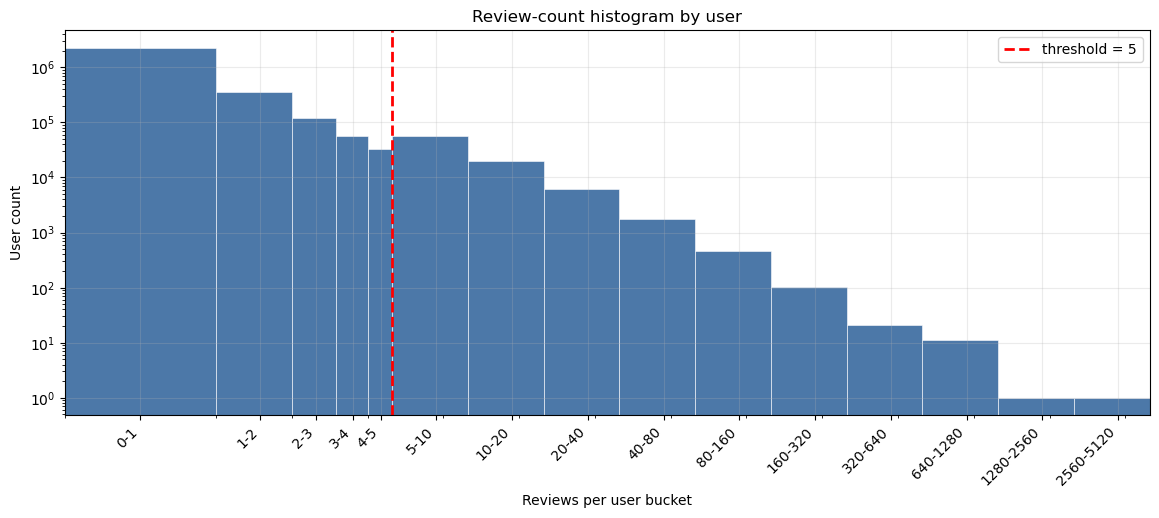

stage_05a diagnostics source: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/raw_reviews_dataset.parquet
steamrec app category mapping source: in-memory dataframe
steamrec item mapping source: in-memory dataframe
Total reviews: 4,798,710
Total unique users: 2,927,350
Users with at least 5 reviews: 118,048 / 2,927,350
Filtered reviews kept for downstream ETL: 1,223,891
Missing mapped app ids in user_review_positions_df: 0
Review count histogram [head]:


,bucket_start,bucket_end,user_count,bucket_label,bucket_center
0,0,1,2279264,0-1,0.5
1,1,2,351641,1-2,1.5
2,2,3,121315,2-3,2.5
3,3,4,57082,3-4,3.5
4,4,5,32483,4-5,4.5
5,5,10,56774,5-10,7.5
6,10,20,20276,10-20,15.0
7,20,40,6174,20-40,30.0
8,40,80,1751,40-80,60.0
9,80,160,455,80-160,120.0


Review count histogram [tail]:


,bucket_start,bucket_end,user_count,bucket_label,bucket_center
0,0,1,2279264,0-1,0.5
1,1,2,351641,1-2,1.5
2,2,3,121315,2-3,2.5
3,3,4,57082,3-4,3.5
4,4,5,32483,4-5,4.5
5,5,10,56774,5-10,7.5
6,10,20,20276,10-20,15.0
7,20,40,6174,20-40,30.0
8,40,80,1751,40-80,60.0
9,80,160,455,80-160,120.0


Review count histogram [summary]:


...

,user_id,app_id,app_category,review_id,timestamp,position,review_score,review_rating
0,76561197960269409,1672,"[2, 1, 34, 23, 16, 12, 18, 19, 42, 44, 46, 56,...",33824283,1501130824,1,1,3
1,76561197960269409,2482,"[2, 12, 17, 18, 13, 40]",60893326,1577688855,2,-1,5
2,76561197960269409,6627,"[2, 12, 36, 37, 40]",146566535,1695088422,3,1,5
3,76561197960269409,7505,"[2, 17, 40]",203695587,1757164570,4,-1,6
4,76561197960269409,7212,"[2, 12, 17, 18, 13, 40]",205132753,1758760076,5,1,0
5,76561197960269409,8959,"[2, 12, 17, 40]",222462157,1775275000,6,1,1
6,76561197960269409,6017,"[2, 12, 17, 40]",222462537,1775275453,7,-1,2
7,76561197960270054,2028,"[2, 17, 18, 6, 40]",41822998,1525324027,1,1,0
8,76561197960270054,3517,"[2, 12, 17, 18, 13, 15, 40]",97842413,1629354244,2,-1,2
9,76561197960270054,4429,"[2, 12, 18, 13, 40]",107778452,1641886527,3,-1,4


User review positions [tail]:


,user_id,app_id,app_category,review_id,timestamp,position,review_score,review_rating
1223871,76561199892395565,9354,"[2, 12, 13]",217944703,1770653044,1,1,0
1223872,76561199892395565,9491,"[2, 12, 13, 40]",221775598,1774557645,2,1,0
1223873,76561199892395565,9584,"[2, 12, 13, 40]",221775660,1774557700,3,1,0
1223874,76561199892395565,9575,"[2, 12, 13, 40]",221775743,1774557768,4,1,0
1223875,76561199892395565,9591,"[2, 12, 46, 57, 13, 40]",222716285,1775534789,5,1,0
1223876,76561199892610583,9163,"[2, 12, 13, 40]",214785135,1767234721,1,1,0
1223877,76561199892610583,9578,"[2, 12, 40]",221229940,1774066067,2,1,0
1223878,76561199892610583,9143,"[2, 12, 40]",221230071,1774066184,3,1,0
1223879,76561199892610583,9285,"[2, 12, 13]",221230202,1774066297,4,1,0
1223880,76561199892610583,9591,"[2, 12, 46, 57, 13, 40]",222471413,1775286465,5,1,0


User review positions [summary]:


,user_id,app_id,app_category,review_id,timestamp,position,review_score,review_rating
0,76561197960269409,1672,"[2, 1, 34, 23, 16, 12, 18, 19, 42, 44, 46, 56,...",33824283,1501130824,1,1,3
1,76561197960269409,2482,"[2, 12, 17, 18, 13, 40]",60893326,1577688855,2,-1,5
2,76561197960269409,6627,"[2, 12, 36, 37, 40]",146566535,1695088422,3,1,5
3,76561197960269409,7505,"[2, 17, 40]",203695587,1757164570,4,-1,6
4,76561197960269409,7212,"[2, 12, 17, 18, 13, 40]",205132753,1758760076,5,1,0
...,...,...,...,...,...,...,...,...
1223886,76561199893346762,22,"[1, 12, 3, 40]",213450888,1765922853,1,1,0
1223887,76561199893346762,2533,"[2, 1, 34, 24, 4, 26, 14, 12, 17, 18, 13, 15, ...",214683092,1767133423,2,-1,0
1223888,76561199893346762,896,"[2, 12, 17, 13, 15, 40]",214683413,1767133669,3,1,0
1223889,76561199893346762,2363,"[2, 1, 34, 24, 12, 17, 13, 15, 21, 31, 40]",219400610,1772245465,4,1,0


In [15]:
import json

import matplotlib.pyplot as plt

# Change these values to move the minimum-review cutoff and the histogram growth point.
# Downstream SteamRec interactions and sequences only keep users with at least USER_REVIEW_COUNT_THRESHOLD reviews.
USER_REVIEW_COUNT_THRESHOLD = 5
USER_REVIEW_COUNT_LINEAR_CUTOFF = 5

STEAMREC_APP_METADATA_CSV_PATH = DATA_DIR / "steamrec_app_metadata.csv"
STEAMREC_APP_CATEGORY_MAPPING_PARQUET_PATH = DATA_DIR / "steamrec_app_category_mapping.parquet"
STEAMREC_APP_CATEGORY_MAPPING_CSV_PATH = DATA_DIR / "steamrec_app_category_mapping.csv"
STEAMREC_ITEM_MAPPING_PARQUET_PATH = DATA_DIR / "steamrec_item_mapping.parquet"
STEAMREC_ITEM_MAPPING_CSV_PATH = DATA_DIR / "steamrec_item_mapping.csv"


def parse_serialized_app_categories(value: object) -> list[int]:
    if value is None:
        return []
    if isinstance(value, list):
        return [int(category_id) for category_id in value]
    if pd.isna(value):
        return []
    text = str(value).strip()
    if not text:
        return []
    return [int(category_id) for category_id in json.loads(text)]


def load_stage_05a_user_source() -> tuple[pd.DataFrame, str]:
    try:
        return (
            pd.read_parquet(
                STAGE_05A_PARQUET_PATH,
                columns=["timestamp", "user_id", "app_id", "review_id", "review_score", "review_rating"],
            ),
            str(STAGE_05A_PARQUET_PATH),
        )
    except OSError as exc:
        print(
            "Falling back to stage_05a_reviews_dataset.csv.gz because raw_reviews_dataset.parquet could not be read "
            f"with the local parquet stack: {exc}"
        )
        return (
            pd.read_csv(
                STAGE_05A_CSV_GZ_PATH,
                usecols=["timestamp", "user_id", "app_id", "review_id", "review_score", "review_rating"],
            ),
            str(STAGE_05A_CSV_GZ_PATH),
        )


def load_mapping_table(parquet_path: Path, csv_path: Path, label: str) -> tuple[pd.DataFrame, str]:
    try:
        return pd.read_parquet(parquet_path), str(parquet_path)
    except OSError as exc:
        print(
            f"Falling back to {csv_path.name} because {parquet_path.name} could not be read "
            f"for {label} with the local parquet stack: {exc}"
        )
        return pd.read_csv(csv_path), str(csv_path)


def review_count_bucket_bounds(review_count: int, linear_cutoff: int = USER_REVIEW_COUNT_LINEAR_CUTOFF) -> tuple[int, int]:
    if review_count <= linear_cutoff:
        return review_count - 1, review_count
    bucket_start = linear_cutoff
    bucket_end = linear_cutoff * 2
    while review_count > bucket_end:
        bucket_start = bucket_end
        bucket_end *= 2
    return bucket_start, bucket_end


if "steamrec_app_category_mapping_df" not in globals():
    steamrec_app_category_mapping_df, steamrec_app_category_mapping_source_path = load_mapping_table(
        STEAMREC_APP_CATEGORY_MAPPING_PARQUET_PATH,
        STEAMREC_APP_CATEGORY_MAPPING_CSV_PATH,
        "steamrec app category mapping",
    )
else:
    steamrec_app_category_mapping_source_path = "in-memory dataframe"
if "steamrec_item_mapping_df" not in globals():
    steamrec_item_mapping_df, steamrec_item_mapping_source_path = load_mapping_table(
        STEAMREC_ITEM_MAPPING_PARQUET_PATH,
        STEAMREC_ITEM_MAPPING_CSV_PATH,
        "steamrec item mapping",
    )
else:
    steamrec_item_mapping_source_path = "in-memory dataframe"
if "steamrec_app_metadata_df" not in globals():
    steamrec_app_metadata_df = pd.read_csv(STEAMREC_APP_METADATA_CSV_PATH)
    steamrec_app_metadata_df["id"] = pd.to_numeric(steamrec_app_metadata_df["id"], errors="coerce").astype("Int64")
    steamrec_app_metadata_df["app_category"] = steamrec_app_metadata_df["app_category"].apply(parse_serialized_app_categories)

steamrec_item_mapping_df = steamrec_item_mapping_df.copy()
steamrec_item_mapping_df["app_id"] = pd.to_numeric(steamrec_item_mapping_df["app_id"], errors="coerce").astype("Int64")
steamrec_item_mapping_df["item_id"] = pd.to_numeric(steamrec_item_mapping_df["item_id"], errors="coerce").astype("Int64")
steamrec_app_category_mapping_df = steamrec_app_category_mapping_df.copy()
steamrec_app_category_mapping_df["app_category"] = pd.to_numeric(steamrec_app_category_mapping_df["app_category"], errors="coerce").astype("Int64")
steamrec_app_category_mapping_df["app_category_id"] = pd.to_numeric(steamrec_app_category_mapping_df["app_category_id"], errors="coerce").astype("Int64")

item_id_lookup = {
    int(app_id): int(item_id)
    for app_id, item_id in steamrec_item_mapping_df[["app_id", "item_id"]].dropna().itertuples(index=False)
}
category_id_lookup = {
    int(app_category): int(app_category_id)
    for app_category_id, app_category in steamrec_app_category_mapping_df[["app_category_id", "app_category"]].dropna().itertuples(index=False)
}
mapped_app_category_lookup = {
    int(app_id): [
        int(category_id_lookup[category_id])
        for category_id in categories
        if int(category_id) in category_id_lookup
    ]
    for app_id, categories in steamrec_app_metadata_df[["id", "app_category"]].dropna(subset=["id"]).itertuples(index=False)
}

stage_05a_user_df, stage_05a_user_source_path = load_stage_05a_user_source()
for column in ["timestamp", "user_id", "app_id", "review_id", "review_score", "review_rating"]:
    stage_05a_user_df[column] = pd.to_numeric(stage_05a_user_df[column], errors="coerce").astype("Int64")

user_review_counts_df = (
    stage_05a_user_df.groupby("user_id", sort=False)
    .size()
    .rename("review_count")
    .reset_index()
    .sort_values(["review_count", "user_id"], ascending=[False, True], kind="stable")
    .reset_index(drop=True)
)
users_at_or_above_threshold_df = user_review_counts_df[
    user_review_counts_df["review_count"] >= USER_REVIEW_COUNT_THRESHOLD
].reset_index(drop=True)
eligible_user_ids = set(users_at_or_above_threshold_df["user_id"].dropna().astype(int).tolist())
stage_05a_filtered_user_df = stage_05a_user_df[
    stage_05a_user_df["user_id"].isin(eligible_user_ids)
].reset_index(drop=True)

review_count_histogram_df = (
    user_review_counts_df.assign(
        bucket_bounds=lambda df: df["review_count"].astype(int).apply(review_count_bucket_bounds)
    )
    .assign(
        bucket_start=lambda df: df["bucket_bounds"].apply(lambda bounds: bounds[0]),
        bucket_end=lambda df: df["bucket_bounds"].apply(lambda bounds: bounds[1]),
    )
    .groupby(["bucket_start", "bucket_end"], sort=True)
    .size()
    .rename("user_count")
    .reset_index()
    .sort_values(["bucket_start", "bucket_end"], kind="stable")
    .reset_index(drop=True)
)
review_count_histogram_df["bucket_label"] = review_count_histogram_df.apply(
    lambda row: f"{int(row['bucket_start'])}-{int(row['bucket_end'])}",
    axis=1,
)
review_count_histogram_df["bucket_center"] = (
    review_count_histogram_df["bucket_start"] + review_count_histogram_df["bucket_end"]
) / 2

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(
    review_count_histogram_df["bucket_start"],
    review_count_histogram_df["user_count"],
    width=review_count_histogram_df["bucket_end"] - review_count_histogram_df["bucket_start"],
    align="edge",
    color="#4C78A8",
    edgecolor="white",
    linewidth=0.4,
)
ax.axvline(
    USER_REVIEW_COUNT_THRESHOLD,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"threshold = {USER_REVIEW_COUNT_THRESHOLD}",
)
ax.set_xscale("symlog", linthresh=1, base=2)
ax.set_yscale("log")
ax.set_xlim(0, int(review_count_histogram_df["bucket_end"].max()))
ax.set_xticks(review_count_histogram_df["bucket_center"])
ax.set_xticklabels(review_count_histogram_df["bucket_label"], rotation=45, ha="right")
ax.set_xlabel("Reviews per user bucket")
ax.set_ylabel("User count")
ax.set_title("Review-count histogram by user")
ax.grid(True, which="major", axis="both", alpha=0.25)
ax.legend()
plt.show()

sorted_stage_05a_user_df = stage_05a_filtered_user_df.sort_values(
    ["user_id", "timestamp", "review_id", "app_id"],
    kind="stable",
).reset_index(drop=True)
sorted_stage_05a_user_df["original_app_id"] = sorted_stage_05a_user_df["app_id"]
sorted_stage_05a_user_df["position"] = sorted_stage_05a_user_df.groupby("user_id").cumcount() + 1
sorted_stage_05a_user_df["app_category"] = sorted_stage_05a_user_df["original_app_id"].apply(
    lambda app_id: mapped_app_category_lookup.get(int(app_id), []) if pd.notna(app_id) else []
)
sorted_stage_05a_user_df["app_id"] = sorted_stage_05a_user_df["original_app_id"].apply(
    lambda app_id: item_id_lookup.get(int(app_id), pd.NA) if pd.notna(app_id) else pd.NA
).astype("Int64")
user_review_positions_df = sorted_stage_05a_user_df[
    ["user_id", "app_id", "app_category", "review_id", "timestamp", "position", "review_score", "review_rating"]
].reset_index(drop=True)

missing_item_mapping_count = int(user_review_positions_df["app_id"].isna().sum())
print(f"stage_05a diagnostics source: {stage_05a_user_source_path}")
print(f"steamrec app category mapping source: {steamrec_app_category_mapping_source_path}")
print(f"steamrec item mapping source: {steamrec_item_mapping_source_path}")
print(f"Total reviews: {len(stage_05a_user_df):,}")
print(f"Total unique users: {len(user_review_counts_df):,}")
print(
    f"Users with at least {USER_REVIEW_COUNT_THRESHOLD} reviews: "
    f"{len(users_at_or_above_threshold_df):,} / {len(user_review_counts_df):,}"
)
print(f"Filtered reviews kept for downstream ETL: {len(stage_05a_filtered_user_df):,}")
print(f"Missing mapped app ids in user_review_positions_df: {missing_item_mapping_count:,}")
print("Review count histogram [head]:")
display(review_count_histogram_df.head(20))
print("Review count histogram [tail]:")
display(review_count_histogram_df.tail(20))
print("Review count histogram [summary]:")
display(review_count_histogram_df)
print("User review counts [head]:")
display(user_review_counts_df.head(20))
print("User review counts [tail]:")
display(user_review_counts_df.tail(20))
print("User review counts [summary]:")
display(user_review_counts_df)
print("Users at or above threshold [head]:")
display(users_at_or_above_threshold_df.head(20))
print("Users at or above threshold [tail]:")
display(users_at_or_above_threshold_df.tail(20))
print("Users at or above threshold [summary]:")
display(users_at_or_above_threshold_df)
print("User review positions [head]:")
display(user_review_positions_df.head(20))
print("User review positions [tail]:")
display(user_review_positions_df.tail(20))
print("User review positions [summary]:")
display(user_review_positions_df)


## SteamRec Interactions ETL

This section reshapes `user_review_positions_df` into the SteamRec interactions table.
It renames the mapped app id to `item_id`, renames `review_score` to `rating`, renames `review_rating` to `review_upvotes`, writes both CSV and parquet outputs, and leaves the mapped category-id arrays attached to each interaction.

In [16]:
from steam_crawler.transforms import minified_json

STEAMREC_INTERACTIONS_PARQUET_PATH = DATA_DIR / "steamrec_interactions.parquet"
STEAMREC_INTERACTIONS_CSV_PATH = DATA_DIR / "steamrec_interactions.csv"

# Reuse the mapped Stage 5a interaction table and rename the fields expected downstream.
steamrec_interactions_df = user_review_positions_df.rename(
    columns={
        "app_id": "item_id",
        "review_score": "rating",
        "review_rating": "review_upvotes",
    }
).copy()

for column in ["user_id", "item_id", "review_id", "timestamp", "position", "rating", "review_upvotes"]:
    steamrec_interactions_df[column] = pd.to_numeric(steamrec_interactions_df[column], errors="coerce").astype("Int64")

steamrec_interactions_df["app_category"] = steamrec_interactions_df["app_category"].apply(
    lambda values: [int(category_id) for category_id in values] if isinstance(values, list) else []
)

steamrec_interactions_df.to_parquet(STEAMREC_INTERACTIONS_PARQUET_PATH, index=False)
steamrec_interactions_csv_df = steamrec_interactions_df.copy()
steamrec_interactions_csv_df["app_category"] = steamrec_interactions_csv_df["app_category"].apply(minified_json)
steamrec_interactions_csv_df.to_csv(STEAMREC_INTERACTIONS_CSV_PATH, index=False)

steamrec_interactions_summary_df = pd.DataFrame(
    {
        "dtype": steamrec_interactions_df.dtypes.astype(str),
        "null_count": steamrec_interactions_df.isna().sum(),
    }
)

print(f"steamrec_interactions parquet: {STEAMREC_INTERACTIONS_PARQUET_PATH}")
print(f"steamrec_interactions csv: {STEAMREC_INTERACTIONS_CSV_PATH}")
display(steamrec_interactions_df.head())
display(steamrec_interactions_summary_df)


steamrec_interactions parquet: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/steamrec_interactions.parquet
steamrec_interactions csv: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/steamrec_interactions.csv


,user_id,item_id,app_category,review_id,timestamp,position,rating,review_upvotes
0,76561197960269409,1672,"[2, 1, 34, 23, 16, 12, 18, 19, 42, 44, 46, 56,...",33824283,1501130824,1,1,3
1,76561197960269409,2482,"[2, 12, 17, 18, 13, 40]",60893326,1577688855,2,-1,5
2,76561197960269409,6627,"[2, 12, 36, 37, 40]",146566535,1695088422,3,1,5
3,76561197960269409,7505,"[2, 17, 40]",203695587,1757164570,4,-1,6
4,76561197960269409,7212,"[2, 12, 17, 18, 13, 40]",205132753,1758760076,5,1,0


,dtype,null_count
user_id,Int64,0
item_id,Int64,0
app_category,object,0
review_id,Int64,0
timestamp,Int64,0
position,Int64,0
rating,Int64,0
review_upvotes,Int64,0


## SteamRec Sequences ETL

This section reshapes `steamrec_interactions` into one row per `user_id` for sequential recommendation work.
It keeps the mapped SteamRec ids in the final sequence columns, derives the train / validation / test splits from review order, and attaches aligned per-review metadata arrays for timestamps, ratings, review upvotes, mapped categories, app review counts, app average ratings, and app prices.

In [17]:
import json

from steam_crawler.transforms import minified_json

STEAMREC_SEQUENCES_PARQUET_PATH = DATA_DIR / "steamrec_sequences.parquet"
STEAMREC_SEQUENCES_CSV_PATH = DATA_DIR / "steamrec_sequences.csv"
STEAMREC_INTERACTIONS_PARQUET_PATH = DATA_DIR / "steamrec_interactions.parquet"
STEAMREC_INTERACTIONS_CSV_PATH = DATA_DIR / "steamrec_interactions.csv"
STEAMREC_APP_METADATA_PARQUET_PATH = DATA_DIR / "steamrec_app_metadata.parquet"
STEAMREC_APP_METADATA_CSV_PATH = DATA_DIR / "steamrec_app_metadata.csv"
STEAMREC_ITEM_MAPPING_PARQUET_PATH = DATA_DIR / "steamrec_item_mapping.parquet"
STEAMREC_ITEM_MAPPING_CSV_PATH = DATA_DIR / "steamrec_item_mapping.csv"


def parse_serialized_int_list(value: object) -> list[int]:
    if value is None:
        return []
    if hasattr(value, "tolist") and not isinstance(value, (str, bytes)):
        value = value.tolist()
    if isinstance(value, tuple):
        value = list(value)
    if isinstance(value, list):
        return [int(item) for item in value]
    try:
        if pd.isna(value):
            return []
    except TypeError:
        pass
    text = str(value).strip()
    if not text:
        return []
    return [int(item) for item in json.loads(text)]


def load_table_with_csv_fallback(parquet_path: Path, csv_path: Path, label: str) -> tuple[pd.DataFrame, str]:
    try:
        return pd.read_parquet(parquet_path), str(parquet_path)
    except OSError as exc:
        print(
            f"Falling back to {csv_path.name} because {parquet_path.name} could not be read "
            f"for {label} with the local parquet stack: {exc}"
        )
        return pd.read_csv(csv_path), str(csv_path)


if "steamrec_interactions_df" not in globals():
    steamrec_interactions_df, steamrec_interactions_source_path = load_table_with_csv_fallback(
        STEAMREC_INTERACTIONS_PARQUET_PATH,
        STEAMREC_INTERACTIONS_CSV_PATH,
        "steamrec interactions",
    )
else:
    steamrec_interactions_source_path = "in-memory dataframe"
if "steamrec_app_metadata_df" not in globals():
    steamrec_app_metadata_df, steamrec_app_metadata_source_path = load_table_with_csv_fallback(
        STEAMREC_APP_METADATA_PARQUET_PATH,
        STEAMREC_APP_METADATA_CSV_PATH,
        "steamrec app metadata",
    )
else:
    steamrec_app_metadata_source_path = "in-memory dataframe"
if "steamrec_item_mapping_df" not in globals():
    steamrec_item_mapping_df, steamrec_item_mapping_source_path = load_table_with_csv_fallback(
        STEAMREC_ITEM_MAPPING_PARQUET_PATH,
        STEAMREC_ITEM_MAPPING_CSV_PATH,
        "steamrec item mapping",
    )
else:
    steamrec_item_mapping_source_path = "in-memory dataframe"

steamrec_interactions_df = steamrec_interactions_df.copy()
for column in ["user_id", "item_id", "review_id", "timestamp", "position", "rating", "review_upvotes"]:
    steamrec_interactions_df[column] = pd.to_numeric(steamrec_interactions_df[column], errors="coerce").astype("Int64")
steamrec_interactions_df["app_category"] = steamrec_interactions_df["app_category"].apply(parse_serialized_int_list)

steamrec_app_metadata_df = steamrec_app_metadata_df.copy()
steamrec_app_metadata_df["id"] = pd.to_numeric(steamrec_app_metadata_df["id"], errors="coerce").astype("Int64")
steamrec_app_metadata_df["num_reviews"] = pd.to_numeric(steamrec_app_metadata_df["num_reviews"], errors="coerce").astype("Int64")
steamrec_app_metadata_df["%positive_reviews"] = pd.to_numeric(steamrec_app_metadata_df["%positive_reviews"], errors="coerce").astype("Float64")
steamrec_app_metadata_df["price"] = pd.to_numeric(steamrec_app_metadata_df["price"], errors="coerce").astype("Float64")

steamrec_item_mapping_df = steamrec_item_mapping_df.copy()
steamrec_item_mapping_df["app_id"] = pd.to_numeric(steamrec_item_mapping_df["app_id"], errors="coerce").astype("Int64")
steamrec_item_mapping_df["item_id"] = pd.to_numeric(steamrec_item_mapping_df["item_id"], errors="coerce").astype("Int64")

item_metadata_df = steamrec_item_mapping_df.merge(
    steamrec_app_metadata_df[["id", "num_reviews", "%positive_reviews", "price"]],
    left_on="app_id",
    right_on="id",
    how="left",
)
item_metadata_lookup = {
    int(item_id): {
        "app_num_reviews": int(num_reviews) if pd.notna(num_reviews) else None,
        "app_avg_rating": float(app_avg_rating) if pd.notna(app_avg_rating) else None,
        "app_price": float(price) if pd.notna(price) else None,
    }
    for item_id, num_reviews, app_avg_rating, price in item_metadata_df[["item_id", "num_reviews", "%positive_reviews", "price"]].dropna(subset=["item_id"]).itertuples(index=False)
}

sequence_rows: list[dict[str, object]] = []
for user_id, frame in steamrec_interactions_df.groupby("user_id", sort=True):
    ordered_frame = frame.sort_values(["position", "timestamp", "review_id", "item_id"], kind="stable").reset_index(drop=True)

    test_sequence: list[int] = []
    timestamps: list[int | None] = []
    ratings: list[int | None] = []
    review_upvotes: list[int | None] = []
    app_category: list[list[int]] = []
    app_num_reviews: list[int | None] = []
    app_avg_rating: list[float | None] = []
    app_price: list[float | None] = []

    for row in ordered_frame.itertuples(index=False):
        if pd.isna(row.item_id):
            continue
        item_id = int(row.item_id)
        test_sequence.append(item_id)
        timestamps.append(int(row.timestamp) if pd.notna(row.timestamp) else None)
        ratings.append(int(row.rating) if pd.notna(row.rating) else None)
        review_upvotes.append(int(row.review_upvotes) if pd.notna(row.review_upvotes) else None)
        categories = row.app_category if isinstance(row.app_category, list) else []
        app_category.append([int(category_id) for category_id in categories])
        metadata = item_metadata_lookup.get(item_id, {})
        app_num_reviews.append(metadata.get("app_num_reviews"))
        app_avg_rating.append(metadata.get("app_avg_rating"))
        app_price.append(metadata.get("app_price"))

    sequence_rows.append(
        {
            "user_id": int(user_id),
            "sequence_length": len(test_sequence),
            "train_sequence": test_sequence[:-2],
            "validation_sequence": test_sequence[:-1],
            "test_sequence": test_sequence,
            "validation_target": test_sequence[-2] if len(test_sequence) >= 2 else pd.NA,
            "test_target": test_sequence[-1] if test_sequence else pd.NA,
            "timestamps": timestamps,
            "ratings": ratings,
            "review_upvotes": review_upvotes,
            "app_category": app_category,
            "app_num_reviews": app_num_reviews,
            "app_avg_rating": app_avg_rating,
            "app_price": app_price,
        }
    )

steamrec_sequences_df = pd.DataFrame(sequence_rows)
for column in ["user_id", "sequence_length", "validation_target", "test_target"]:
    steamrec_sequences_df[column] = pd.to_numeric(steamrec_sequences_df[column], errors="coerce").astype("Int64")

steamrec_sequences_df.to_parquet(STEAMREC_SEQUENCES_PARQUET_PATH, index=False)
steamrec_sequences_csv_df = steamrec_sequences_df.copy()
for column in [
    "train_sequence",
    "validation_sequence",
    "test_sequence",
    "timestamps",
    "ratings",
    "review_upvotes",
    "app_category",
    "app_num_reviews",
    "app_avg_rating",
    "app_price",
]:
    steamrec_sequences_csv_df[column] = steamrec_sequences_csv_df[column].apply(minified_json)
steamrec_sequences_csv_df.to_csv(STEAMREC_SEQUENCES_CSV_PATH, index=False)

steamrec_sequences_summary_df = pd.DataFrame(
    {
        "dtype": steamrec_sequences_df.dtypes.astype(str),
        "null_count": steamrec_sequences_df.isna().sum(),
    }
)

print(f"steamrec interactions source: {steamrec_interactions_source_path}")
print(f"steamrec app metadata source: {steamrec_app_metadata_source_path}")
print(f"steamrec item mapping source: {steamrec_item_mapping_source_path}")
print(f"steamrec_sequences parquet: {STEAMREC_SEQUENCES_PARQUET_PATH}")
print(f"steamrec_sequences csv: {STEAMREC_SEQUENCES_CSV_PATH}")
display(steamrec_sequences_df.head())
display(steamrec_sequences_summary_df)


steamrec interactions source: in-memory dataframe
steamrec app metadata source: in-memory dataframe
steamrec item mapping source: in-memory dataframe
steamrec_sequences parquet: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/steamrec_sequences.parquet
steamrec_sequences csv: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/steamrec_sequences.csv


,user_id,sequence_length,train_sequence,validation_sequence,test_sequence,validation_target,test_target,timestamps,ratings,review_upvotes,app_category,app_num_reviews,app_avg_rating,app_price
0,76561197960269409,7,"[1672, 2482, 6627, 7505, 7212]","[1672, 2482, 6627, 7505, 7212, 8959]","[1672, 2482, 6627, 7505, 7212, 8959, 6017]",8959,6017,"[1501130824, 1577688855, 1695088422, 175716457...","[1, -1, 1, -1, 1, 1, -1]","[3, 5, 5, 6, 0, 1, 2]","[[2, 1, 34, 23, 16, 12, 18, 19, 42, 44, 46, 56...","[568, 1025, 813, 1406, 1053, 2853, 10857]","[0.71, 0.62, 0.84, 0.78, 0.86, 0.97, 0.94]","[3.74, 19.99, 39.99, 29.99, 19.99, 4.99, 8.74]"
1,76561197960270054,18,"[2028, 3517, 4429, 6930, 2768, 6852, 7428, 677...","[2028, 3517, 4429, 6930, 2768, 6852, 7428, 677...","[2028, 3517, 4429, 6930, 2768, 6852, 7428, 677...",7855,7782,"[1525324027, 1629354244, 1641886527, 170601582...","[1, -1, -1, 1, -1, -1, -1, -1, -1, 1, -1, -1, ...","[0, 2, 4, 0, 2, 2, 9, 2, 0, 0, 1, 4, 1, 0, 1, ...","[[2, 17, 18, 6, 40], [2, 12, 17, 18, 13, 15, 4...","[653, 711, 1000, 1073, 563, 555, 918, 1608, 12...","[0.49, 0.71, 0.49, 0.77, 0.85, 0.95, 0.79, 0.7...","[1.99, 24.99, 2.99, 19.99, 9.99, 29.99, 12.99,..."
2,76561197960270613,10,"[1054, 3563, 2908, 6381, 366, 7321, 1309, 3672]","[1054, 3563, 2908, 6381, 366, 7321, 1309, 3672...","[1054, 3563, 2908, 6381, 366, 7321, 1309, 3672...",6849,5901,"[1574565753, 1653457913, 1681180831, 172075397...","[1, -1, -1, 1, 1, 1, -1, 1, 1, 1]","[1, 0, 1, 0, 2, 1, 0, 0, 0, 2]","[[2, 12, 18, 10, 13, 40], [2, 12, 18, 10, 13, ...","[503, 689, 1583, 1582, 1966, 1463, 973, 2090, ...","[0.95, 0.69, 0.9, 0.78, 0.57, 0.93, 0.59, 0.82...","[7.99, 14.99, 19.99, 11.99, 14.99, 19.99, 9.99..."
3,76561197960271099,6,"[4082, 8307, 2149, 7106]","[4082, 8307, 2149, 7106, 8428]","[4082, 8307, 2149, 7106, 8428, 1396]",8428,1396,"[1730317669, 1754805076, 1759679992, 177273377...","[1, -1, -1, -1, -1, -1]","[2, 5, 1, 1, 5, 6]","[[2, 1, 11, 4, 25, 12, 40], [2, 12, 17, 13, 40...","[1211, 1261, 5454, 2327, 662, 7146]","[0.87, 0.86, 0.9, 0.88, 0.88, 0.85]","[15.99, 9.99, 14.99, 19.99, 19.99, 19.99]"
4,76561197960271496,5,"[2810, 2544, 3143]","[2810, 2544, 3143, 1236]","[2810, 2544, 3143, 1236, 5805]",1236,5805,"[1491667208, 1515940845, 1520092964, 162500764...","[1, 1, 1, -1, -1]","[1, 0, 0, 2, 0]","[[2, 36, 38, 40], [2, 36, 37, 5, 10, 40], [2, ...","[544, 560, 573, 1017, 1290]","[0.88, 0.82, 0.83, 0.83, 0.92]","[15.99, 9.69, 29.99, 14.99, 19.99]"


,dtype,null_count
user_id,Int64,0
sequence_length,Int64,0
train_sequence,object,0
validation_sequence,object,0
test_sequence,object,0
validation_target,Int64,0
test_target,Int64,0
timestamps,object,0
ratings,object,0
review_upvotes,object,0


In [18]:
# Reuse the same Kaggle dataset handle so the raw stage parquet files and downstream ETL outputs live in one dataset.
KAGGLE_SHARED_DATASET_HANDLE = f"{KAGGLE_USERNAME}/steam-cs5242-dataset"

STEAMREC_APP_CATEGORY_MAPPING_PARQUET_PATH = DATA_DIR / "steamrec_app_category_mapping.parquet"
STEAMREC_ITEM_MAPPING_PARQUET_PATH = DATA_DIR / "steamrec_item_mapping.parquet"
STEAMREC_SEQUENCES_PARQUET_PATH = DATA_DIR / "steamrec_sequences.parquet"
FINAL_ITEM_MAPPING_PARQUET_PATH = DATA_DIR / "final_item_mapping.parquet"

if STEAMREC_ITEM_MAPPING_PARQUET_PATH.exists():
    final_item_mapping_df = pd.read_parquet(STEAMREC_ITEM_MAPPING_PARQUET_PATH).rename(
        columns={"app_id": "app_package"}
    )
    if "app_package" not in final_item_mapping_df.columns:
        raise KeyError("Expected app_id to be renamed to app_package for final_item_mapping.parquet")
    if "app_id" in final_item_mapping_df.columns:
        raise KeyError("final_item_mapping.parquet must expose app_package, not app_id")
    final_item_mapping_df.to_parquet(FINAL_ITEM_MAPPING_PARQUET_PATH, index=False)
    print(f"final_item_mapping parquet: {FINAL_ITEM_MAPPING_PARQUET_PATH}")
else:
    print(f"Skipping final_item_mapping alias because source is missing: {STEAMREC_ITEM_MAPPING_PARQUET_PATH}")

steamrec_kaggle_dataset_files = {
    "raw_selected_games.parquet": STAGE_04A_PARQUET_PATH,
    "raw_reviews_dataset.parquet": STAGE_05A_PARQUET_PATH,
    "steamrec_app_metadata.parquet": DATA_DIR / "steamrec_app_metadata.parquet",
    "steamrec_app_category_mapping.parquet": STEAMREC_APP_CATEGORY_MAPPING_PARQUET_PATH,
    "steamrec_item_mapping.parquet": STEAMREC_ITEM_MAPPING_PARQUET_PATH,
    "steamrec_interactions.parquet": DATA_DIR / "steamrec_interactions.parquet",
    "steamrec_sequences.parquet": STEAMREC_SEQUENCES_PARQUET_PATH,
    "final_app_category.parquet": STEAMREC_APP_CATEGORY_MAPPING_PARQUET_PATH,
    "final_item_mapping.parquet": FINAL_ITEM_MAPPING_PARQUET_PATH,
    "final_sequences.parquet": STEAMREC_SEQUENCES_PARQUET_PATH,
}

steamrec_kaggle_upload = upload_kaggle_dataset_snapshot(
    KAGGLE_SHARED_DATASET_HANDLE,
    steamrec_kaggle_dataset_files,
    version_notes=f"Refresh shared SteamRec dataset artifacts after notebook sequences ETL update {dt.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}",
)

steamrec_kaggle_upload


final_item_mapping parquet: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/final_item_mapping.parquet
Uploading Dataset https://api.kaggle.com/datasets/gitaalekhyapaul/steam-cs5242-dataset ...
Starting upload for file /var/folders/fg/p6f6x7z11qb2jtk9d1gdsdlw0000gn/T/kagglehub_dataset_qzt2ejzp/raw_selected_games.parquet


Uploading: 100%|██████████| 258k/258k [00:01<00:00, 190kB/s]

Upload successful: /var/folders/fg/p6f6x7z11qb2jtk9d1gdsdlw0000gn/T/kagglehub_dataset_qzt2ejzp/raw_selected_games.parquet (252KB)
Starting upload for file /var/folders/fg/p6f6x7z11qb2jtk9d1gdsdlw0000gn/T/kagglehub_dataset_qzt2ejzp/raw_reviews_dataset.parquet



Uploading: 100%|██████████| 113M/113M [00:10<00:00, 11.2MB/s] 

Upload successful: /var/folders/fg/p6f6x7z11qb2jtk9d1gdsdlw0000gn/T/kagglehub_dataset_qzt2ejzp/raw_reviews_dataset.parquet (108MB)
Starting upload for file /var/folders/fg/p6f6x7z11qb2jtk9d1gdsdlw0000gn/T/kagglehub_dataset_qzt2ejzp/steamrec_sequences.parquet


...

Upload successful: /var/folders/fg/p6f6x7z11qb2jtk9d1gdsdlw0000gn/T/kagglehub_dataset_qzt2ejzp/steamrec_interactions.parquet (25MB)
Starting upload for file /var/folders/fg/p6f6x7z11qb2jtk9d1gdsdlw0000gn/T/kagglehub_dataset_qzt2ejzp/steamrec_app_category_mapping.parquet



Uploading: 100%|██████████| 3.28k/3.28k [00:00<00:00, 3.40kB/s]

Upload successful: /var/folders/fg/p6f6x7z11qb2jtk9d1gdsdlw0000gn/T/kagglehub_dataset_qzt2ejzp/steamrec_app_category_mapping.parquet (3KB)


Your dataset version has been created.
Files are being processed...
See at: https://api.kaggle.com/datasets/gitaalekhyapaul/steam-cs5242-dataset
Uploaded 10 parquet file(s) to https://www.kaggle.com/datasets/gitaalekhyapaul/steam-cs5242-dataset
- raw_selected_games.parquet: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/raw_selected_games.parquet
- raw_reviews_dataset.parquet: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/raw_reviews_dataset.parquet
- steamrec_app_metadata.parquet: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/steamrec_app_metadata.parquet
- steamrec_app_category_mapping.parquet: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/steamrec_app_category_mapping.parquet
- steamrec_item_mapping.parquet: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/steamrec_item_mapping.parquet
- steamrec_interactions.

{'handle': 'gitaalekhyapaul/steam-cs5242-dataset',
 'url': 'https://www.kaggle.com/datasets/gitaalekhyapaul/steam-cs5242-dataset',
 'files': {'raw_selected_games.parquet': '/Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/raw_selected_games.parquet',
  'raw_reviews_dataset.parquet': '/Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/raw_reviews_dataset.parquet',
  'steamrec_app_metadata.parquet': '/Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/steamrec_app_metadata.parquet',
  'steamrec_app_category_mapping.parquet': '/Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/steamrec_app_category_mapping.parquet',
  'steamrec_item_mapping.parquet': '/Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/steamrec_item_mapping.parquet',
  'steamrec_interactions.parquet': '/Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam

## Kaggle Sanity Check

This section downloads the shared Kaggle dataset back to a temporary directory,
confirms that the locally available raw and ETL parquet resources are present, and previews the downloaded files.


In [19]:
import time

import pandas as pd
from IPython.display import display

KAGGLE_SHARED_DATASET_HANDLE = f"{KAGGLE_USERNAME}/steam-cs5242-dataset"
STEAMREC_APP_CATEGORY_MAPPING_PARQUET_PATH = DATA_DIR / "steamrec_app_category_mapping.parquet"
STEAMREC_ITEM_MAPPING_PARQUET_PATH = DATA_DIR / "steamrec_item_mapping.parquet"
STEAMREC_SEQUENCES_PARQUET_PATH = DATA_DIR / "steamrec_sequences.parquet"
FINAL_ITEM_MAPPING_PARQUET_PATH = DATA_DIR / "final_item_mapping.parquet"
if STEAMREC_ITEM_MAPPING_PARQUET_PATH.exists():
    final_item_mapping_df = pd.read_parquet(STEAMREC_ITEM_MAPPING_PARQUET_PATH).rename(
        columns={"app_id": "app_package"}
    )
    if "app_package" not in final_item_mapping_df.columns:
        raise KeyError("Expected app_id to be renamed to app_package for final_item_mapping.parquet")
    if "app_id" in final_item_mapping_df.columns:
        raise KeyError("final_item_mapping.parquet must expose app_package, not app_id")
    final_item_mapping_df.to_parquet(FINAL_ITEM_MAPPING_PARQUET_PATH, index=False)
    print(f"final_item_mapping parquet: {FINAL_ITEM_MAPPING_PARQUET_PATH}")
KAGGLE_EXPECTED_DATASET_FILES = {
    name: path
    for name, path in {
        "raw_selected_games.parquet": STAGE_04A_PARQUET_PATH,
        "raw_reviews_dataset.parquet": STAGE_05A_PARQUET_PATH,
        "steamrec_app_metadata.parquet": DATA_DIR / "steamrec_app_metadata.parquet",
        "steamrec_app_category_mapping.parquet": STEAMREC_APP_CATEGORY_MAPPING_PARQUET_PATH,
        "steamrec_item_mapping.parquet": STEAMREC_ITEM_MAPPING_PARQUET_PATH,
        "steamrec_interactions.parquet": DATA_DIR / "steamrec_interactions.parquet",
        "steamrec_sequences.parquet": STEAMREC_SEQUENCES_PARQUET_PATH,
        "final_app_category.parquet": STEAMREC_APP_CATEGORY_MAPPING_PARQUET_PATH,
        "final_item_mapping.parquet": FINAL_ITEM_MAPPING_PARQUET_PATH,
        "final_sequences.parquet": STEAMREC_SEQUENCES_PARQUET_PATH,
    }.items()
    if Path(path).exists()
}
KAGGLE_DOWNLOAD_MAX_RETRIES = 10
KAGGLE_DOWNLOAD_INITIAL_RETRY_SECONDS = 10
KAGGLE_DOWNLOAD_MAX_RETRY_SECONDS = 300

if not KAGGLE_EXPECTED_DATASET_FILES:
    raise FileNotFoundError("No local parquet files are available for Kaggle verification.")

with TemporaryDirectory(prefix="kagglehub_verify_") as tmp_dir_name:
    base_download_dir = Path(tmp_dir_name)
    downloaded_paths: dict[str, Path] = {}
    missing_files: list[str] = []

    for retry_index in range(KAGGLE_DOWNLOAD_MAX_RETRIES + 1):
        attempt = retry_index + 1
        attempt_dir = base_download_dir / f"attempt_{attempt}"
        attempt_dir.mkdir(parents=True, exist_ok=True)
        resolved_download_dir = Path(
            kagglehub.dataset_download(
                KAGGLE_SHARED_DATASET_HANDLE,
                output_dir=str(attempt_dir),
                force_download=True,
            )
        )
        downloaded_paths = {
            resource_name: resolved_download_dir / resource_name
            for resource_name in KAGGLE_EXPECTED_DATASET_FILES
        }
        missing_files = [
            resource_name
            for resource_name, downloaded_path in downloaded_paths.items()
            if not downloaded_path.exists()
        ]
        if not missing_files:
            print(f"Downloaded Kaggle dataset snapshot from {resolved_download_dir}")
            break
        if retry_index == KAGGLE_DOWNLOAD_MAX_RETRIES:
            raise RuntimeError(
                "Missing Kaggle parquet resources after "
                f"{KAGGLE_DOWNLOAD_MAX_RETRIES} retries: {missing_files}"
            )
        wait_seconds = min(
            KAGGLE_DOWNLOAD_INITIAL_RETRY_SECONDS * (2 ** retry_index),
            KAGGLE_DOWNLOAD_MAX_RETRY_SECONDS,
        )
        print(
            f"Attempt {attempt}/{KAGGLE_DOWNLOAD_MAX_RETRIES + 1}: still missing {missing_files}. "
            f"Waiting {wait_seconds} seconds before retry {retry_index + 1}/{KAGGLE_DOWNLOAD_MAX_RETRIES}."
        )
        time.sleep(wait_seconds)

    for resource_name, local_source_path in KAGGLE_EXPECTED_DATASET_FILES.items():
        downloaded_path = downloaded_paths[resource_name]
        if not downloaded_path.exists():
            raise FileNotFoundError(
                f"Expected Kaggle resource missing after download: {downloaded_path}"
            )
        try:
            downloaded_df = pd.read_parquet(downloaded_path)
        except OSError as exc:
            print(
                f"{resource_name}: downloaded successfully but preview is unavailable with the local parquet stack: {exc}"
            )
            print(f"Downloaded path: {downloaded_path}")
            continue
        if resource_name == "final_item_mapping.parquet":
            if "app_package" not in downloaded_df.columns or "app_id" in downloaded_df.columns:
                raise AssertionError(
                    "final_item_mapping.parquet must contain app_package and must not contain app_id"
                )
        print(
            f"{resource_name}: uploaded successfully | local source={local_source_path} | "
            f"downloaded rows={downloaded_df.shape[0]:,} | columns={downloaded_df.shape[1]}"
        )
        print(f"Downloaded path: {downloaded_path}")
        print("Head")
        display(downloaded_df.head())
        print("Tail")
        display(downloaded_df.tail())


final_item_mapping parquet: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/final_item_mapping.parquet


100%|██████████| 89.8M/89.8M [00:05<00:00, 16.9MB/s]

Extracting files...


Attempt 1/11: still missing ['steamrec_app_metadata.parquet', 'steamrec_app_category_mapping.parquet', 'steamrec_item_mapping.parquet', 'steamrec_interactions.parquet', 'steamrec_sequences.parquet', 'final_app_category.parquet', 'final_item_mapping.parquet', 'final_sequences.parquet']. Waiting 10 seconds before retry 1/10.


100%|██████████| 89.8M/89.8M [00:09<00:00, 10.3MB/s]

...

,app_package,item_id
9593,4286550,9594
9594,4298880,9595
9595,4309030,9596
9596,4327530,9597
9597,4450800,9598


final_sequences.parquet: uploaded successfully | local source=/Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/steamrec_sequences.parquet | downloaded rows=118,048 | columns=14
Downloaded path: /var/folders/fg/p6f6x7z11qb2jtk9d1gdsdlw0000gn/T/kagglehub_verify_myvyl8bf/attempt_3/final_sequences.parquet
Head


,user_id,sequence_length,train_sequence,validation_sequence,test_sequence,validation_target,test_target,timestamps,ratings,review_upvotes,app_category,app_num_reviews,app_avg_rating,app_price
0,76561197960269409,7,"[1672, 2482, 6627, 7505, 7212]","[1672, 2482, 6627, 7505, 7212, 8959]","[1672, 2482, 6627, 7505, 7212, 8959, 6017]",8959,6017,"[1501130824, 1577688855, 1695088422, 175716457...","[1, -1, 1, -1, 1, 1, -1]","[3, 5, 5, 6, 0, 1, 2]","[[2, 1, 34, 23, 16, 12, 18, 19, 42, 44, 46, 56...","[568, 1025, 813, 1406, 1053, 2853, 10857]","[0.71, 0.62, 0.84, 0.78, 0.86, 0.97, 0.94]","[3.74, 19.99, 39.99, 29.99, 19.99, 4.99, 8.74]"
1,76561197960270054,18,"[2028, 3517, 4429, 6930, 2768, 6852, 7428, 677...","[2028, 3517, 4429, 6930, 2768, 6852, 7428, 677...","[2028, 3517, 4429, 6930, 2768, 6852, 7428, 677...",7855,7782,"[1525324027, 1629354244, 1641886527, 170601582...","[1, -1, -1, 1, -1, -1, -1, -1, -1, 1, -1, -1, ...","[0, 2, 4, 0, 2, 2, 9, 2, 0, 0, 1, 4, 1, 0, 1, ...","[[2, 17, 18, 6, 40], [2, 12, 17, 18, 13, 15, 4...","[653, 711, 1000, 1073, 563, 555, 918, 1608, 12...","[0.49, 0.71, 0.49, 0.77, 0.85, 0.95, 0.79, 0.7...","[1.99, 24.99, 2.99, 19.99, 9.99, 29.99, 12.99,..."
2,76561197960270613,10,"[1054, 3563, 2908, 6381, 366, 7321, 1309, 3672]","[1054, 3563, 2908, 6381, 366, 7321, 1309, 3672...","[1054, 3563, 2908, 6381, 366, 7321, 1309, 3672...",6849,5901,"[1574565753, 1653457913, 1681180831, 172075397...","[1, -1, -1, 1, 1, 1, -1, 1, 1, 1]","[1, 0, 1, 0, 2, 1, 0, 0, 0, 2]","[[2, 12, 18, 10, 13, 40], [2, 12, 18, 10, 13, ...","[503, 689, 1583, 1582, 1966, 1463, 973, 2090, ...","[0.95, 0.69, 0.9, 0.78, 0.57, 0.93, 0.59, 0.82...","[7.99, 14.99, 19.99, 11.99, 14.99, 19.99, 9.99..."
3,76561197960271099,6,"[4082, 8307, 2149, 7106]","[4082, 8307, 2149, 7106, 8428]","[4082, 8307, 2149, 7106, 8428, 1396]",8428,1396,"[1730317669, 1754805076, 1759679992, 177273377...","[1, -1, -1, -1, -1, -1]","[2, 5, 1, 1, 5, 6]","[[2, 1, 11, 4, 25, 12, 40], [2, 12, 17, 13, 40...","[1211, 1261, 5454, 2327, 662, 7146]","[0.87, 0.86, 0.9, 0.88, 0.88, 0.85]","[15.99, 9.99, 14.99, 19.99, 19.99, 19.99]"
4,76561197960271496,5,"[2810, 2544, 3143]","[2810, 2544, 3143, 1236]","[2810, 2544, 3143, 1236, 5805]",1236,5805,"[1491667208, 1515940845, 1520092964, 162500764...","[1, 1, 1, -1, -1]","[1, 0, 0, 2, 0]","[[2, 36, 38, 40], [2, 36, 37, 5, 10, 40], [2, ...","[544, 560, 573, 1017, 1290]","[0.88, 0.82, 0.83, 0.83, 0.92]","[15.99, 9.69, 29.99, 14.99, 19.99]"


Tail


,user_id,sequence_length,train_sequence,validation_sequence,test_sequence,validation_target,test_target,timestamps,ratings,review_upvotes,app_category,app_num_reviews,app_avg_rating,app_price
118043,76561199892349436,5,"[9354, 9491, 9575]","[9354, 9491, 9575, 9584]","[9354, 9491, 9575, 9584, 9591]",9584,9591,"[1770653687, 1774558442, 1774558487, 177455852...","[1, 1, 1, 1, 1]","[0, 1, 0, 0, 0]","[[2, 12, 13], [2, 12, 13, 40], [2, 12, 13, 40]...","[1801, 1962, 1119, 2690, 960]","[0.98, 0.98, 0.93, 0.97, 0.98]","[9.99, 9.99, 4.99, 9.99, 4.99]"
118044,76561199892395565,5,"[9354, 9491, 9584]","[9354, 9491, 9584, 9575]","[9354, 9491, 9584, 9575, 9591]",9575,9591,"[1770653044, 1774557645, 1774557700, 177455776...","[1, 1, 1, 1, 1]","[0, 0, 0, 0, 0]","[[2, 12, 13], [2, 12, 13, 40], [2, 12, 13, 40]...","[1801, 1962, 2690, 1119, 960]","[0.98, 0.98, 0.97, 0.93, 0.98]","[9.99, 9.99, 9.99, 4.99, 4.99]"
118045,76561199892610583,5,"[9163, 9578, 9143]","[9163, 9578, 9143, 9285]","[9163, 9578, 9143, 9285, 9591]",9285,9591,"[1767234721, 1774066067, 1774066184, 177406629...","[1, 1, 1, 1, 1]","[0, 0, 0, 0, 0]","[[2, 12, 13, 40], [2, 12, 40], [2, 12, 40], [2...","[1137, 1023, 2038, 1133, 960]","[0.96, 0.95, 0.93, 0.94, 0.98]","[10.99, 3.99, 19.99, 8.99, 4.99]"
118046,76561199893069284,5,"[9354, 9580, 9575]","[9354, 9580, 9575, 9285]","[9354, 9580, 9575, 9285, 9591]",9285,9591,"[1769695722, 1772908244, 1773847582, 177415816...","[1, 1, 1, 1, 1]","[0, 0, 0, 0, 0]","[[2, 12, 13], [2, 12, 13, 40], [2, 12, 13, 40]...","[1801, 2002, 1119, 1133, 960]","[0.98, 0.96, 0.93, 0.94, 0.98]","[9.99, 14.99, 4.99, 8.99, 4.99]"
118047,76561199893346762,5,"[22, 2533, 896]","[22, 2533, 896, 2363]","[22, 2533, 896, 2363, 3955]",2363,3955,"[1765922853, 1767133423, 1767133669, 177224546...","[1, -1, 1, 1, 1]","[0, 0, 0, 0, 1]","[[1, 12, 3, 40], [2, 1, 34, 24, 4, 26, 14, 12,...","[1503, 1309, 4871, 3708, 11750]","[0.88, 0.92, 0.96, 0.8, 0.95]","[4.99, 4.99, 9.99, 49.99, 5.99]"


In [20]:
import datetime as dt

ETL_END_TIME = dt.datetime.now().astimezone()
if "ETL_START_TIME" in globals():
    print(f"ETL start: {ETL_START_TIME.isoformat(timespec='seconds')}")
    print(f"ETL end:   {ETL_END_TIME.isoformat(timespec='seconds')}")
    print(f"Elapsed:   {ETL_END_TIME - ETL_START_TIME}")
else:
    print("ETL start: not captured in this kernel run; run the first setup cell first.")
    print(f"ETL end:   {ETL_END_TIME.isoformat(timespec='seconds')}")

ETL start: 2026-04-23T20:54:11+08:00
ETL end:   2026-04-23T20:59:23+08:00
Elapsed:   0:05:11.374191
